<a href="https://colab.research.google.com/github/Hion-cy/ClassFiles/blob/main/ProyectoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Maestría en Inteligencia Artificial y Analítica de Datos
##Procesamiento del lenguaje natural
**Matrícula:** AL263158

**Alumna:** Carmen Yolanda Hion Vela

#Proyecto Final: Predicción de síntomas médicos

#Descripción
En este proyecto desarrollarán un sistema para la predicción de síntomas médicos a partir de datos textuales recogidos de registros o transcripciones médicas. El objetivo es aplicar técnicas de PLN para preprocesar, representar, modelar y evaluar el texto con foco en aplicaciones de salud.

El dataset contiene ejemplos de diferentes síntomas médicos descritos en formato textual con el objetivo de construir modelos que puedan identificar el síntoma presente en una entrada dada. Cada muestra pertenece a una de varias clases que representan síntomas o condiciones comunes reportadas por pacientes.


#Librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from sklearn.preprocessing import LabelEncoder
!pip install unidecode
from unidecode import unidecode
from wordcloud import WordCloud
!pip install gensim matplotlib scikit-learn
from gensim.models import KeyedVectors
from sentence_transformers import SentenceTransformer
import gensim.downloader as api
from collections import Counter
from sklearn.manifold import TSNE
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import ParameterGrid
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import v_measure_score
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.utils import resample

#Carga de datos


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
texto=pd.read_csv('/content/drive/MyDrive/NPL/Dataset.csv')
print('Estructura del dataset')
print(texto.info())

print('\nPrimeras 5 filas del dataset')
print(texto.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Estructura del dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6661 entries, 0 to 6660
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   phrase  6661 non-null   object
 1   prompt  6661 non-null   object
dtypes: object(2)
memory usage: 104.2+ KB
None

Primeras 5 filas del dataset
                                              phrase            prompt
0                    When I remember her I feel down    Emotional pain
1  When I carry heavy things I feel like breaking...  Hair falling out
2          there is too much pain when i move my arm       Heart hurts
3  My son had his lip pierced and it is swollen a...    Infected wound
4             My muscles in my lower back are aching    Infected wound


##Observaciones:


* El dataset no cuenta con datos nulos.
* Se compone de dos columnas: phrase y prompt.
* Los datos se encuentran en idioma inglés.
* Existen 6661 registros en el dataset.
* De acuerdo a las instrucciones del proyecto, la variable objetivo es **prompt** o los síntomas.


#Análisis de los datos

## Distribución de las clases

In [ ]:
print('Distribucion de las clases (Sintomas)')
print(texto['prompt'].value_counts())

Distribucion de las clases (Sintomas)
prompt
Acne                  328
Shoulder pain         320
Joint pain            318
Infected wound        306
Knee pain             305
Cough                 293
Feeling dizzy         283
Muscle pain           282
Heart hurts           273
Ear ache              270
Hair falling out      264
Feeling cold          263
Head ache             263
Skin issue            262
Stomach ache          261
Back pain             259
Neck pain             251
Internal pain         248
Blurry vision         246
Body feels weak       241
Hard to breath        233
Emotional pain        231
Injury from sports    230
Foot ache             223
Open wound            208
Name: count, dtype: int64


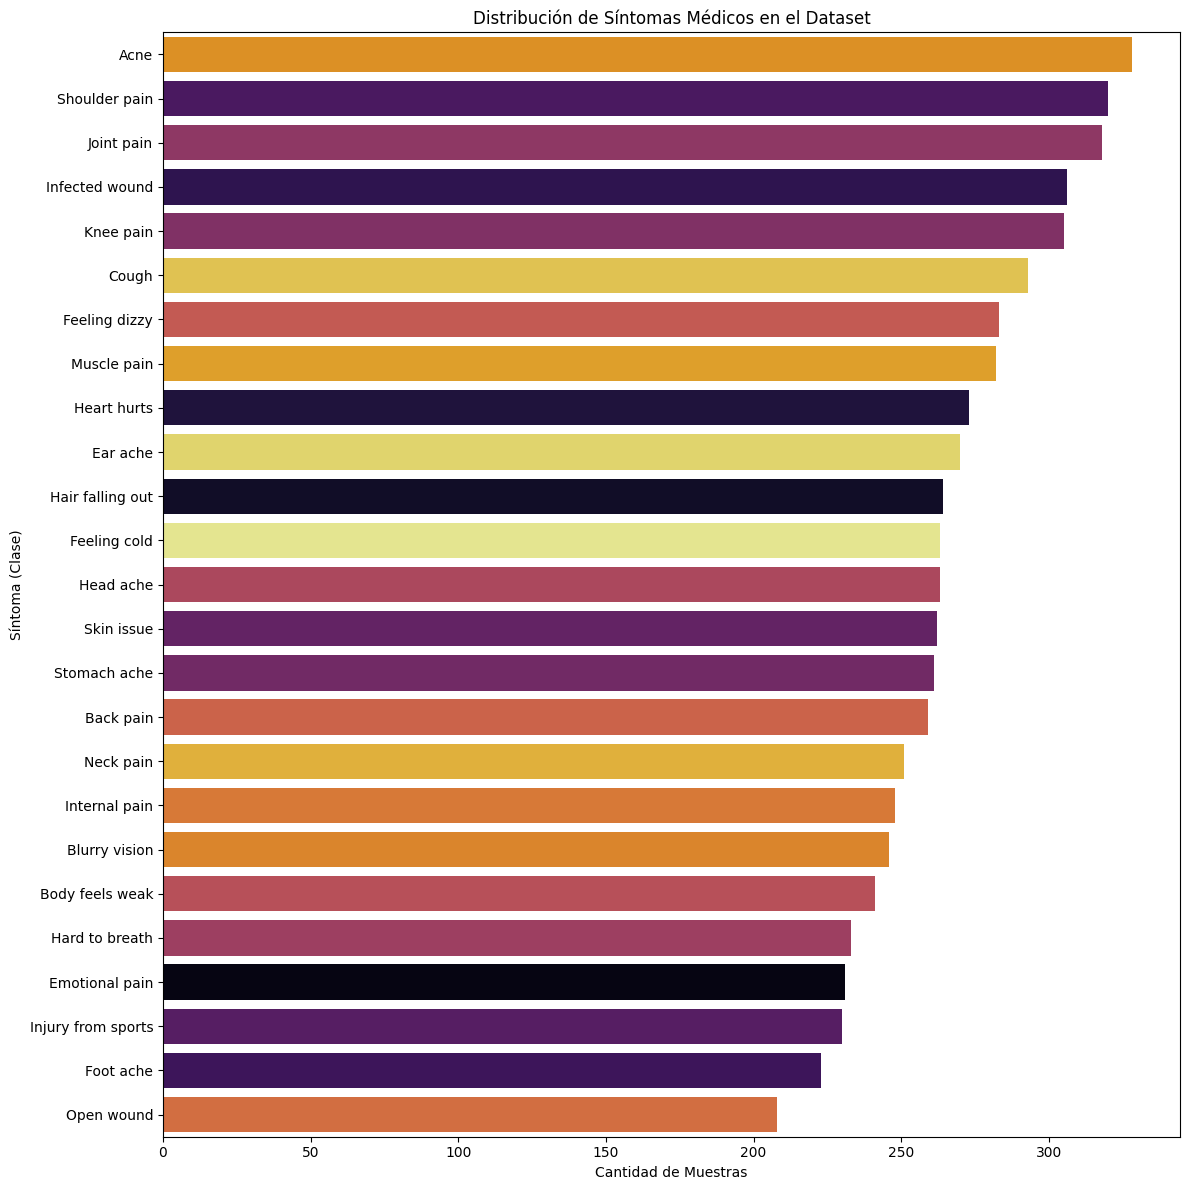

In [ ]:
plt.figure(figsize=(12, 12))
sns.countplot(y=texto['prompt'], order=texto['prompt'].value_counts().index, palette='inferno', hue=texto['prompt'])
plt.title('Distribución de Síntomas Médicos en el Dataset')
plt.xlabel('Cantidad de Muestras')
plt.ylabel('Síntoma (Clase)')
plt.tight_layout()
plt.show()

In [ ]:
texto['longitud_texto'] = texto['phrase'].astype(str).apply(lambda x: len(x.split()))
print("\nEstadísticas de longitud de las frases (en palabras)")
print(texto['longitud_texto'].describe())


Estadísticas de longitud de las frases (en palabras)
count    6661.000000
mean       10.543462
std         4.807787
min         2.000000
25%         7.000000
50%        10.000000
75%        13.000000
max        30.000000
Name: longitud_texto, dtype: float64


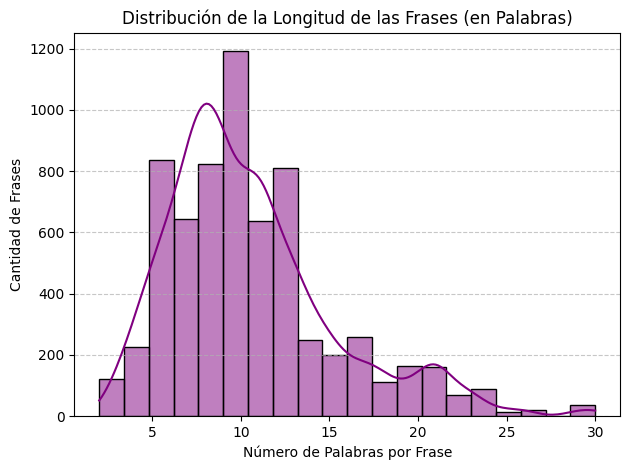

In [ ]:
sns.histplot(texto['longitud_texto'], bins=20, kde=True, color='purple')

plt.title('Distribución de la Longitud de las Frases (en Palabras)')
plt.xlabel('Número de Palabras por Frase')
plt.ylabel('Cantidad de Frases')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

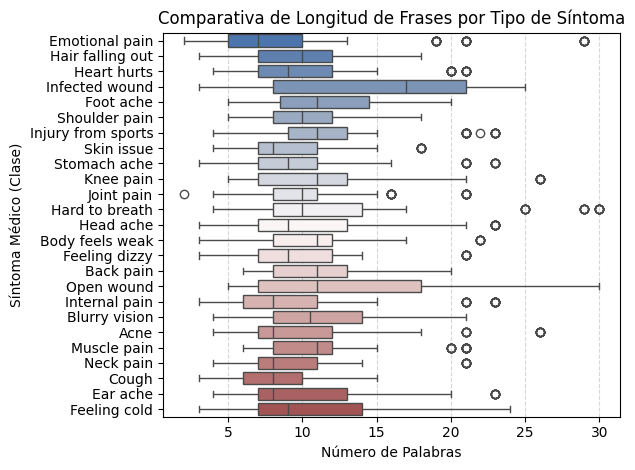

In [ ]:
sns.boxplot(
    x='longitud_texto',
    y='prompt',
    data=texto,
    hue='prompt',
    palette='vlag',
    legend=False
)

plt.title('Comparativa de Longitud de Frases por Tipo de Síntoma')
plt.xlabel('Número de Palabras')
plt.ylabel('Síntoma Médico (Clase)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

##Observaciones
* El sintoma que mas se repite es Acne (acne también en español), mientras que el que menos lo hace es Open wound (herida abierta).
* Cada frase esta compuesta en promedio por alrededor de 10 palabras.
* La frase mas corta contiene 2 palabras y la más larga 30.
* En el diagrama de caja se observa la longitud de las frases por tipo se sintoma donde se observan dos fenómenos importantes:
1. La presencia de valores atípicos o outliers en clases como Hard to breathe (Dificultad para respirar) o Emotional pain (Dolor emocional) lo que demuestra que aunque los pacientes tienden a reportar estos sintomas con frases cortas, existen excepciones que utilizan muchas mas palabras del promedio.
2. La categoria que se destaca por tener la dispersión mas uniforme es Open wound (Herida abierta), esto significa que el texto varia proporcionalemente en todos los casos.

#Preprocesamiento y Normalización


In [ ]:
nltk.download('stopwords')
stop_words_en = stopwords.words('english')

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'[^\w\s]', '', texto)
    texto= unidecode(texto)
    palabras = texto.split()
    palabras_filtradas = [w for w in palabras if w not in stop_words_en]
    return palabras_filtradas

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
texto['tokens'] = texto['phrase'].apply(limpiar_texto)


label_encoder = LabelEncoder()
texto['target'] = label_encoder.fit_transform(texto['prompt'])

mapeo_prompt=texto[['prompt', 'target']].drop_duplicates().sort_values('target').reset_index(drop=True)
print(mapeo_prompt)

print("\nDataset con Preprocesamiento y Normalización\n")
print(texto.head(3))

                prompt  target
0                 Acne       0
1            Back pain       1
2        Blurry vision       2
3      Body feels weak       3
4                Cough       4
5             Ear ache       5
6       Emotional pain       6
7         Feeling cold       7
8        Feeling dizzy       8
9            Foot ache       9
10    Hair falling out      10
11      Hard to breath      11
12           Head ache      12
13         Heart hurts      13
14      Infected wound      14
15  Injury from sports      15
16       Internal pain      16
17          Joint pain      17
18           Knee pain      18
19         Muscle pain      19
20           Neck pain      20
21          Open wound      21
22       Shoulder pain      22
23          Skin issue      23
24        Stomach ache      24

Dataset con Preprocesamiento y Normalización

                                              phrase            prompt  \
0                    When I remember her I feel down    Emotional pain   

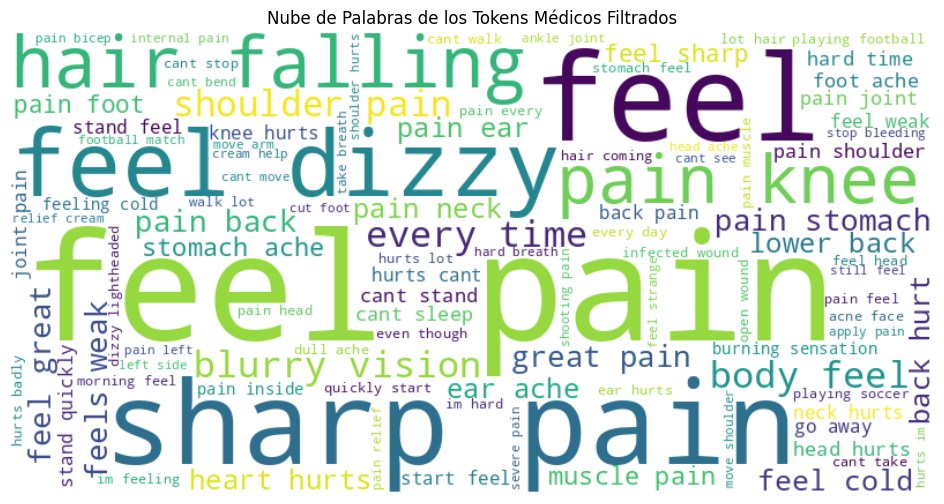

In [ ]:
todos_los_tokens = [token for lista in texto['tokens'] for token in lista]
texto_completo_nube = " ".join(todos_los_tokens)
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(texto_completo_nube)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de Palabras de los Tokens Médicos Filtrados')
plt.show()


##Observaciones
En la nube de palabras se identifican palabras que se asocian con otras como feel pain (sentir dolor), feel dizzy (sentirse mareado) o pain knee (dolor en la rodilla). Esto refleja la alta frecuencia y coocurrencia visual de estas palabras clave dentro de las descripciones clínicas de los pacientes.

#Vectorizacion y embeddings

##CountVectorizer

In [ ]:
print("Ejecutando Vectorizaciones Tradicionales")
print('Bag of words')

vectorizer= CountVectorizer(strip_accents='unicode' )
X_parametros=vectorizer.fit_transform(texto['tokens'].apply(lambda x: ' '.join(x)))
bow_df= pd.DataFrame(
    X_parametros.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=[f"d{i+1}" for i in range(len(texto['tokens'].apply(lambda x: ' '.join(x))))]
)

print(f"Matriz Bag of Words generada. Forma: {X_parametros.shape}")
print("Muestra de la matriz generada")
print(bow_df.iloc[0:10, 10:25])

Ejecutando Vectorizaciones Tradicionales
Bag of words
Matriz Bag of Words generada. Forma: (6661, 1057)
Muestra de la matriz generada
     accidentally  accompanied  ache  aches  aching  acne  across  active  \
d1              0            0     0      0       0     0       0       0   
d2              0            0     0      0       0     0       0       0   
d3              0            0     0      0       0     0       0       0   
d4              0            0     0      0       0     0       0       0   
d5              0            0     0      0       1     0       0       0   
d6              0            0     0      0       0     0       0       0   
d7              0            0     0      0       0     0       0       0   
d8              0            0     0      0       0     0       0       0   
d9              0            0     0      0       0     1       0       0   
d10             0            0     0      0       0     0       0       0   

     actually  acu

###Observaciones
Al implementar el algoritmo CountVecorizer se genero una matriz dispersa de dimensiones 6661 X 1057(Registros en el dataset original X Terminos ortograficos unicos).

En el muestreo de la matriz se observan multiples valores en 0 debido a la ausencia de los terminos en las declaraciones de cada paciente. Esto debido a que no todos describen los síntomas usando las mismas palabras.

##TDIDF

In [ ]:
print('TFIDF')
vectorizer_tfidf = TfidfVectorizer()
X_tfidf = vectorizer_tfidf.fit_transform(texto['tokens'].apply(lambda x: ' '.join(x)))
Tfid_df = pd.DataFrame(
  X_tfidf.toarray(),
  columns=vectorizer.get_feature_names_out(),
 index=[f"d{i+1}" for i in range(X_tfidf.shape[0])])

print(f"Matriz TFIDF. Forma: {X_tfidf.shape}")
print("Muestra de la matriz generada")
print(Tfid_df.iloc[0:10, 10:25])

TFIDF
Matriz TFIDF. Forma: (6661, 1057)
Muestra de la matriz generada
     accidentally  accompanied  ache  aches   aching      acne  across  \
d1            0.0          0.0   0.0    0.0  0.00000  0.000000     0.0   
d2            0.0          0.0   0.0    0.0  0.00000  0.000000     0.0   
d3            0.0          0.0   0.0    0.0  0.00000  0.000000     0.0   
d4            0.0          0.0   0.0    0.0  0.00000  0.000000     0.0   
d5            0.0          0.0   0.0    0.0  0.57047  0.000000     0.0   
d6            0.0          0.0   0.0    0.0  0.00000  0.000000     0.0   
d7            0.0          0.0   0.0    0.0  0.00000  0.000000     0.0   
d8            0.0          0.0   0.0    0.0  0.00000  0.000000     0.0   
d9            0.0          0.0   0.0    0.0  0.00000  0.336524     0.0   
d10           0.0          0.0   0.0    0.0  0.00000  0.000000     0.0   

     active  actually  acupunctures  adult  affected  afraid  ago  agreat  
d1      0.0       0.0           0.0    

###Observaciones
Al utilizazr el modelo TfidfVectorizer, se mantiene la estructura de 6661X1057 pero los datos de la internos de la muestra de la matriz cambian  de conteos a pesos continuos normalizados.

La variación matemática mostrada en columas como 'Acne' con valor de 0.336524 comparado con otros como 'Aching' de 0.57047 demuestra que el esquema se ha equilibrado para identificar aquellos terminos donde los sintomas especificos aportan mayor contexto.

Esto permite atenuar el impacto de palabras genéricas e identificar con mayor precisión aquellos términos donde los síntomas específicos de los pacientes aportan un mayor valor contextual y discriminativo para los modelos de clasificación.

##Embeddings

In [ ]:
print(" Generación de Embeddings Contextuales con BERT")
model_bert = SentenceTransformer('all-MiniLM-L6-v2')
frases_completas = texto['tokens'].apply(lambda x: ' '.join(x)).tolist()
print(f"Procesando {len(frases_completas)} descripciones médicas...")
X_bert = model_bert.encode(frases_completas, show_progress_bar=True)
X_bert = np.array(X_bert)
print("\n BERT Embedding")
print(f"Matriz de BERT generada. Forma: {X_bert.shape}")

 Generación de Embeddings Contextuales con BERT


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Procesando 6661 descripciones médicas...


Batches:   0%|          | 0/209 [00:00<?, ?it/s]


 BERT Embedding
Matriz de BERT generada. Forma: (6661, 384)


In [ ]:
bert_df = pd.DataFrame(X_bert, index=[f"d{i+1}" for i in range(X_bert.shape[0])])
print("Muestra de la matriz de  BERT ----")
# Mostramos los primeros 5 pacientes y sus primeras 10 dimensiones vectoriales
print(bert_df.iloc[0:5, 0:10])

Muestra de la matriz de  BERT ----
           0         1         2         3         4         5         6  \
d1 -0.010644 -0.072810  0.004347  0.048666  0.029279  0.021184  0.081559   
d2 -0.023962 -0.043384  0.062313  0.091680  0.033421 -0.038529  0.101579   
d3  0.017574 -0.008938  0.052613  0.013913 -0.015110 -0.055166  0.067798   
d4 -0.073362 -0.016558  0.005242 -0.001830 -0.063213 -0.077146  0.064767   
d5 -0.022223 -0.040951  0.018002  0.087709 -0.082037 -0.057123 -0.072296   

           7         8         9  
d1  0.052378  0.057501 -0.064709  
d2  0.012776 -0.043427 -0.002327  
d3  0.044067  0.115850  0.007951  
d4  0.038865 -0.081460 -0.032328  
d5  0.048333  0.042657 -0.031983  


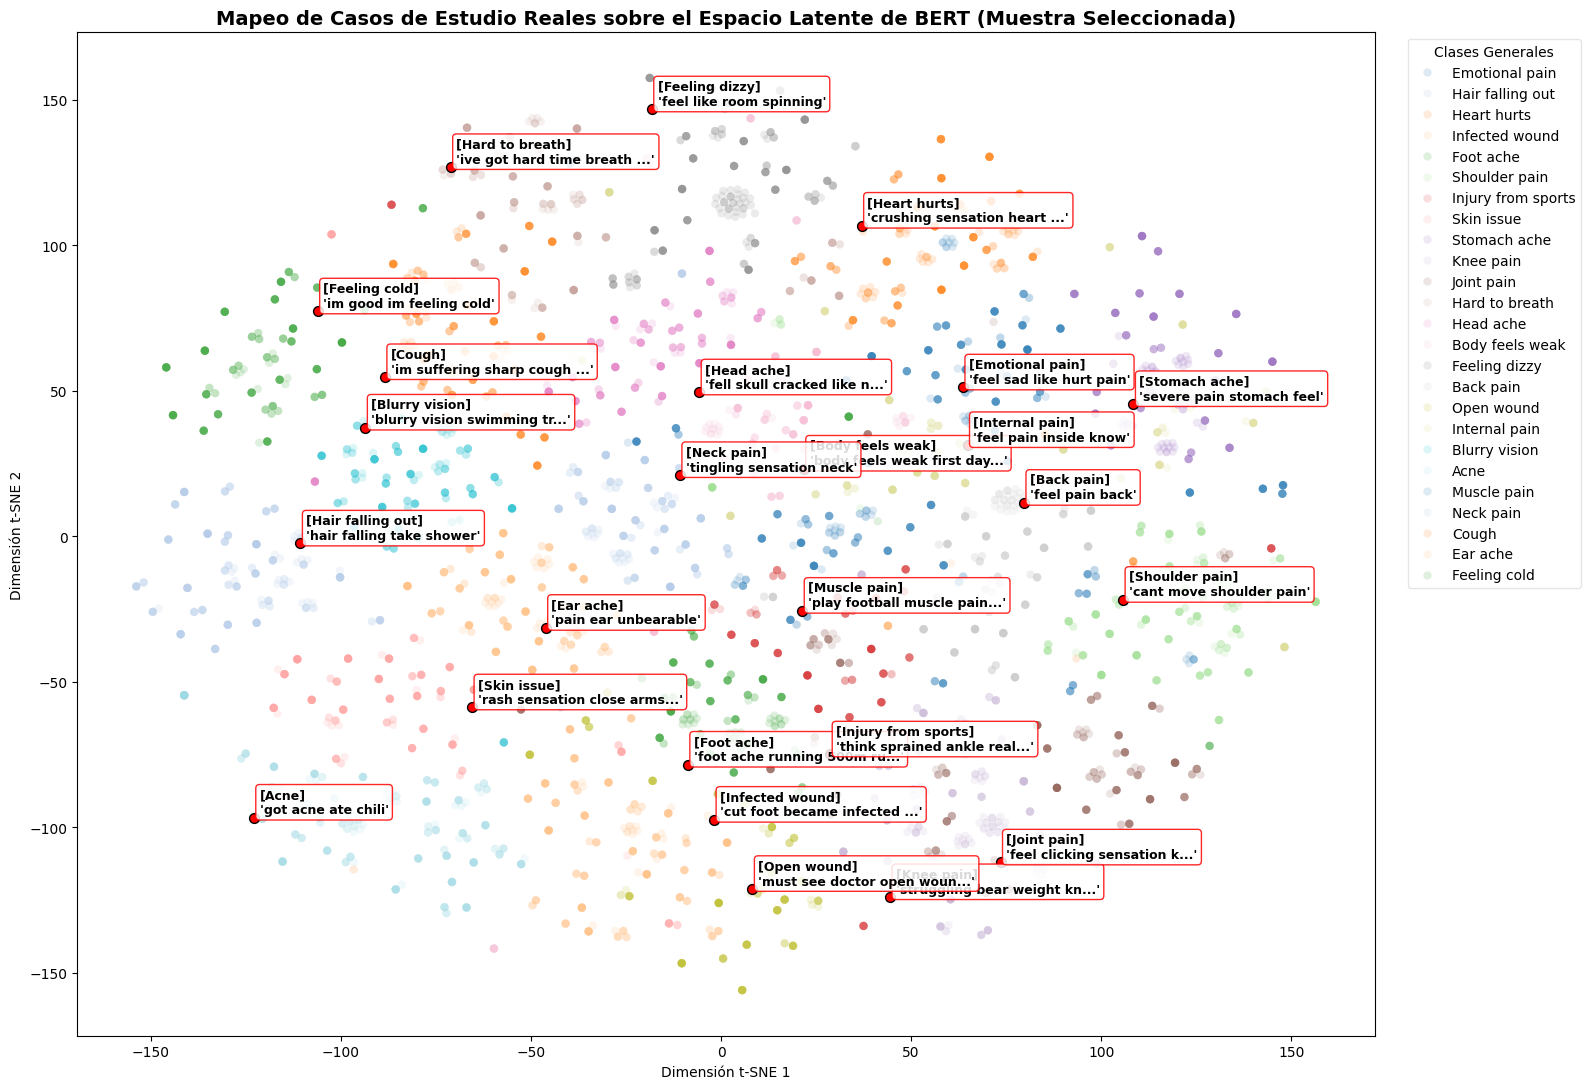

In [ ]:
tsne = TSNE(n_components=2, random_state=42)
X_2d = tsne.fit_transform(X_bert)
texto_completo = texto['tokens'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x)).values

plt.figure(figsize=(16, 11))
sns.scatterplot(
    x=X_2d[:, 0],
    y=X_2d[:, 1],
    hue=texto['prompt'],
    palette='tab20',
    alpha=0.15,
    edgecolor='none'
)

np.random.seed(42)
indices_muestra = []
for clase in texto['prompt'].unique():
    indices_clase = np.where(texto['prompt'] == clase)[0]
    if len(indices_clase) > 0:
        indices_muestra.append(np.random.choice(indices_clase))

for idx in indices_muestra:
    x, y = X_2d[idx, 0], X_2d[idx, 1]
    sintoma_real = texto['prompt'].iloc[idx]
    frase_paciente = texto_completo[idx]
    frase_corta = frase_paciente if len(frase_paciente) < 25 else frase_paciente[:25] + "..."

    plt.scatter(x, y, c="red", s=50, zorder=5, edgecolor='black')
    plt.text(
        x + 1.5, y + 1.5,
        f"[{sintoma_real}]\n'{frase_corta}'",
        fontsize=9,
        fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='red', boxstyle='round,pad=0.3'),
        zorder=6
    )

plt.title('Mapeo de Casos de Estudio Reales sobre el Espacio Latente de BERT (Muestra Seleccionada)', fontsize=14, fontweight='bold')
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Clases Generales', framealpha=0.5)

plt.tight_layout()
plt.show()

###Observaciones
* El tamaño de la matriz que resulta de utilizar BERT se reduce a 6661 X 384, que es un numero muy pequeño en comparación con el resultado de los vectores.
* La desaparicion de los multiples 0s en la matriz, demuestra que se elimina la dispersión en los resultados, dando paso a un espacio numerico continuo donde cada resultado aporta valor.
* La gráfica demuestra que el modelo funciona perfectamente porque fue capaz de agrupar de forma automática los síntomas similares (como los dolores musculares o los respiratorios) en las mismas zonas del mapa, sin mezclar temas que no tienen relación.

#Entrenamiento
Tres modelos distintos y optimización, ajustando sus parámetros (puedes utilizar GridSearch).

##K-Means


###GridSearch


In [ ]:
param_grid_kmeans = {
    'n_clusters': [4, 5, 6, 7, 8, 9, 10],
}

best_km_score = -1
best_km_params = None

print("Iniciando GridSearch para K-Means")

for params in ParameterGrid(param_grid_kmeans):
    kmeans = KMeans(
        n_clusters=params['n_clusters'],
        random_state=42,
        n_init=10
    )

    preds = kmeans.fit_predict(X_2d)

    score = silhouette_score(X_2d, preds)
    print(f"Probando: {params['n_clusters']} grupos -> Silhouette Score: {score:.4f}")

    if score > best_km_score:
        best_km_score = score
        best_km_params = params
print(f"¡PROCESO TERMINADO!")
print(f"La mejor combinación es: {best_km_params}")
print(f"Su Silhouette Score más alto fue: {best_km_score:.4f}")

Iniciando GridSearch para K-Means
Probando: 4 grupos -> Silhouette Score: 0.3578
Probando: 5 grupos -> Silhouette Score: 0.3388
Probando: 6 grupos -> Silhouette Score: 0.3660
Probando: 7 grupos -> Silhouette Score: 0.3663
Probando: 8 grupos -> Silhouette Score: 0.3545
Probando: 9 grupos -> Silhouette Score: 0.3532
Probando: 10 grupos -> Silhouette Score: 0.3489
¡PROCESO TERMINADO!
La mejor combinación es: {'n_clusters': 7}
Su Silhouette Score más alto fue: 0.3663


### Entrenamiento del modelo

In [ ]:
print('Entrenando K-Means')
cluster_optimos=7
kmeans = KMeans(
    n_clusters=cluster_optimos,
    random_state=42,
    n_init=10
)
preds = kmeans.fit_predict(X_2d)
texto['cluster_kmeans'] = preds

print("\n¡Entrenamiento completado!")
print("Los pacientes han sido asignados a los clústeres del 0 al 6.")
print("Muestra de las asignaciones:")
print(texto[['prompt', 'cluster_kmeans']].head(10))

Entrenando K-Means

¡Entrenamiento completado!
Los pacientes han sido asignados a los clústeres del 0 al 6.
Muestra de las asignaciones:
               prompt  cluster_kmeans
0      Emotional pain               3
1    Hair falling out               1
2         Heart hurts               1
3      Infected wound               4
4      Infected wound               1
5           Foot ache               5
6       Shoulder pain               5
7  Injury from sports               5
8          Skin issue               4
9           Foot ache               4


/tmp/ipykernel_4394/485546393.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


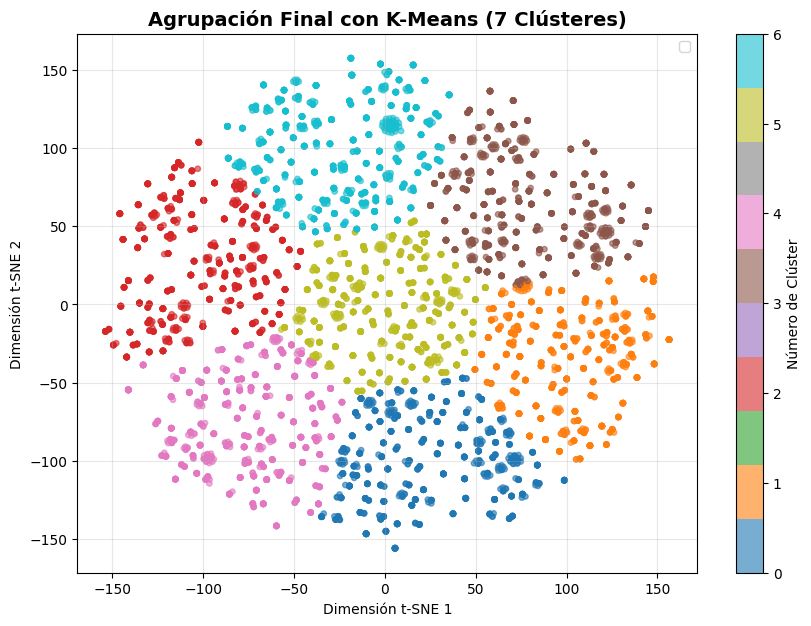

In [ ]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=texto['cluster_kmeans'], cmap='tab10', alpha=0.6, s=15)


plt.title('Agrupación Final con K-Means (7 Clústeres)', fontsize=14, fontweight='bold')
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')
plt.colorbar(scatter, label='Número de Clúster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

###Observaciones
* Usando la GridSearch se observo que el numero de clusters mas adecuado para el conjunto de datos es 7, ya que este valor aporta el valor mas alto en Silouette antes de que comience a bajar.
* La gráfica de disperción muestra que existe una distribucion visualmente uniforme solidifica la decision de utilizar K=7.


##DBSCAN


###GridSearch

In [ ]:
param_grid_dbscan = {
    'eps': [3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0],
    'min_samples': [5, 10, 15]
}

best_db_score = -1
best_db_params = None
ganador_grupos = 0
ganador_ruido = 0
print("Iniciando GridSearch para DBSCAN")

for params in ParameterGrid(param_grid_dbscan):
    dbscan = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    preds_db = dbscan.fit_predict(X_2d)

    n_grupos = len(set(preds_db)) - (1 if -1 in preds_db else 0)
    n_ruido = np.sum(preds_db == -1)

    mascara_no_ruido = preds_db != -1
    if n_grupos > 1 and np.sum(mascara_no_ruido) > 0:
        score = silhouette_score(X_2d[mascara_no_ruido], preds_db[mascara_no_ruido])
        print(f"Probando: eps={params['eps']} \n\tmin_samples={params['min_samples']} \n\tGrupos: {n_grupos} \n\tRuido: {n_ruido} \n\tSilhouette: {score:.4f}")

        if score > best_db_score:
            best_db_score = score
            best_db_params = params
            ganador_grupos = n_grupos
            ganador_ruido = n_ruido
    else:
        print(f"Probando: eps={params['eps']}, min_samples={params['min_samples']} -> Combinación inválida (No formó suficientes grupos)")

print(f"La MEJOR combinación es: {best_db_params}")
print(f"Encontró {ganador_grupos} grupos de síntomas y aisló {ganador_ruido} puntos como ruido.")
print(f"Su Silhouette Score fue de: {best_db_score:.4f}")

Iniciando GridSearch para DBSCAN
Probando: eps=3.0 
	min_samples=5 
	Grupos: 679 
	Ruido: 2 
	Silhouette: 0.8991
Probando: eps=3.0 
	min_samples=10 
	Grupos: 369 
	Ruido: 2550 
	Silhouette: 0.9001
Probando: eps=3.0 
	min_samples=15 
	Grupos: 9 
	Ruido: 6501 
	Silhouette: 0.9721
Probando: eps=4.0 
	min_samples=5 
	Grupos: 672 
	Ruido: 0 
	Silhouette: 0.8962
Probando: eps=4.0 
	min_samples=10 
	Grupos: 367 
	Ruido: 2494 
	Silhouette: 0.8927
Probando: eps=4.0 
	min_samples=15 
	Grupos: 18 
	Ruido: 6293 
	Silhouette: 0.9147
Probando: eps=5.0 
	min_samples=5 
	Grupos: 636 
	Ruido: 0 
	Silhouette: 0.8648
Probando: eps=5.0 
	min_samples=10 
	Grupos: 356 
	Ruido: 2304 
	Silhouette: 0.8521
Probando: eps=5.0 
	min_samples=15 
	Grupos: 38 
	Ruido: 5844 
	Silhouette: 0.8080
Probando: eps=6.0 
	min_samples=5 
	Grupos: 555 
	Ruido: 0 
	Silhouette: 0.7605
Probando: eps=6.0 
	min_samples=10 
	Grupos: 321 
	Ruido: 1953 
	Silhouette: 0.7267
Probando: eps=6.0 
	min_samples=15 
	Grupos: 71 
	Ruido: 4949 


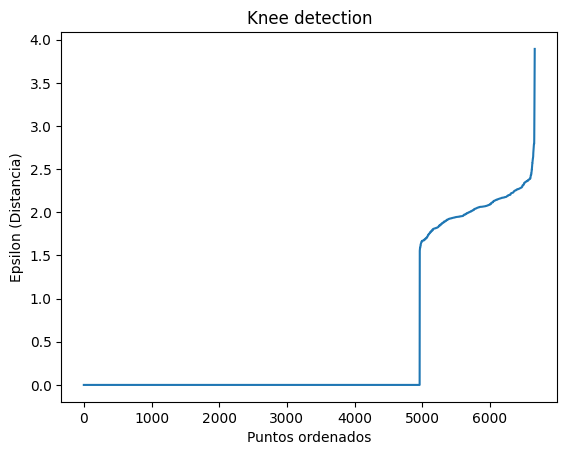

In [ ]:
neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(X_2d)
distances, indices = neighbors_fit.kneighbors(X_2d)

distances = np.sort(distances[:, 4], axis=0)
plt.plot(distances)
plt.ylabel("Epsilon (Distancia)")
plt.xlabel("Puntos ordenados")
plt.title("Knee detection")
plt.show()

In [ ]:
param_grid_dbscan = {
    'eps': [1.5,1.6,1.7,1.8,1.9,2,2.1,2.2,2.3,2.4,2.5],
    'min_samples': [5, 10, 15]
}

best_db_score = -1
best_db_params = None
ganador_grupos = 0
ganador_ruido = 0
print("Reiniciando GridSearch para DBSCAN ")

for params in ParameterGrid(param_grid_dbscan):
    dbscan = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    preds_db = dbscan.fit_predict(X_2d)

    n_grupos = len(set(preds_db)) - (1 if -1 in preds_db else 0)
    n_ruido = np.sum(preds_db == -1)

    mascara_no_ruido = preds_db != -1
    if n_grupos > 1 and np.sum(mascara_no_ruido) > 0:
        score = silhouette_score(X_2d[mascara_no_ruido], preds_db[mascara_no_ruido])
        print(f"Probando: eps={params['eps']} \n\tmin_samples={params['min_samples']} \n\tGrupos: {n_grupos} \n\tRuido: {n_ruido} \n\tSilhouette: {score:.4f}")

        if score > best_db_score:
            best_db_score = score
            best_db_params = params
            ganador_grupos = n_grupos
            ganador_ruido = n_ruido
    else:
        print(f"Probando: eps={params['eps']}, min_samples={params['min_samples']} -> Combinación inválida (No formó suficientes grupos)")

print(f"La MEJOR combinación es: {best_db_params}")
print(f"Encontró {ganador_grupos} grupos de síntomas y aisló {ganador_ruido} puntos como ruido.")
print(f"Su Silhouette Score fue de: {best_db_score:.4f}")

Reiniciando GridSearch para DBSCAN 
Probando: eps=1.5 
	min_samples=5 
	Grupos: 607 
	Ruido: 1700 
	Silhouette: 1.0000
Probando: eps=1.5 
	min_samples=10 
	Grupos: 169 
	Ruido: 4838 
	Silhouette: 1.0000
Probando: eps=1.5 
	min_samples=15 
	Grupos: 2 
	Ruido: 6625 
	Silhouette: 1.0000
Probando: eps=1.6 
	min_samples=5 
	Grupos: 615 
	Ruido: 1654 
	Silhouette: 0.9976
Probando: eps=1.6 
	min_samples=10 
	Grupos: 169 
	Ruido: 4838 
	Silhouette: 1.0000
Probando: eps=1.6 
	min_samples=15 
	Grupos: 2 
	Ruido: 6625 
	Silhouette: 1.0000
Probando: eps=1.7 
	min_samples=5 
	Grupos: 635 
	Ruido: 1504 
	Silhouette: 0.9908
Probando: eps=1.7 
	min_samples=10 
	Grupos: 169 
	Ruido: 4838 
	Silhouette: 1.0000
Probando: eps=1.7 
	min_samples=15 
	Grupos: 2 
	Ruido: 6625 
	Silhouette: 1.0000
Probando: eps=1.8 
	min_samples=5 
	Grupos: 655 
	Ruido: 1342 
	Silhouette: 0.9815
Probando: eps=1.8 
	min_samples=10 
	Grupos: 169 
	Ruido: 4838 
	Silhouette: 1.0000
Probando: eps=1.8 
	min_samples=15 
	Grupos: 2 
	R

In [ ]:
dbscan_final = DBSCAN(eps=2, min_samples=5)
mis_labels_dbscan = dbscan_final.fit_predict(X_2d)

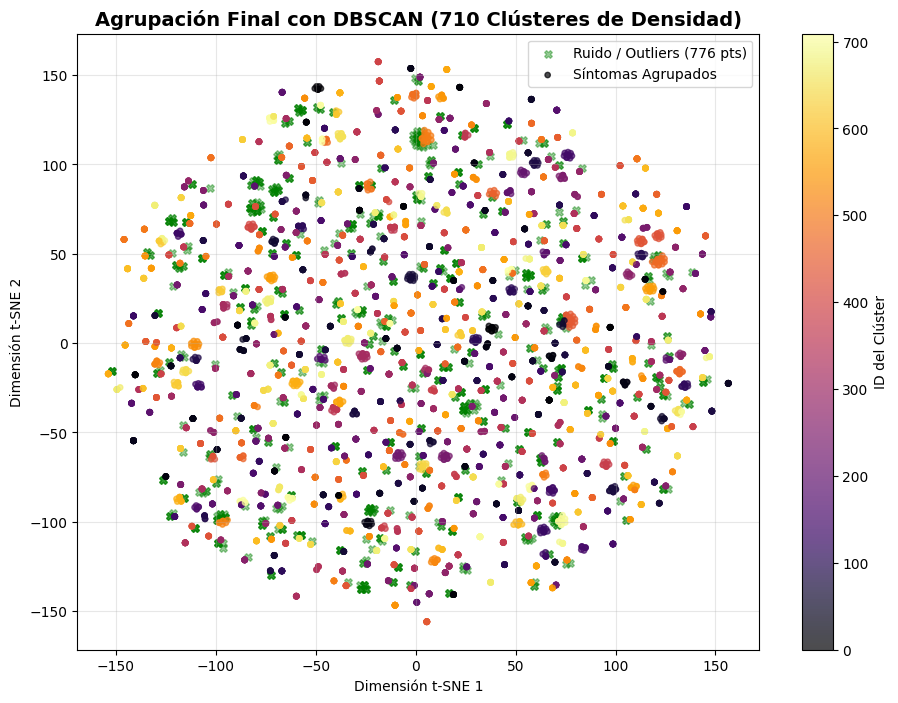

In [ ]:
texto['cluster_dbscan'] = mis_labels_dbscan
ruido_detectado=mis_labels_dbscan==-1
n_grupos_db = len(set(mis_labels_dbscan)) - (1 if -1 in mis_labels_dbscan else 0)
n_ruido_db = np.sum(ruido_detectado)

plt.figure(figsize=(11, 8))
if n_ruido_db > 0:
  plt.scatter(
    X_2d[ruido_detectado, 0], X_2d[ruido_detectado, 1],
    c='green', alpha=0.4, s=30, marker='X',
    label=f'Ruido / Outliers ({n_ruido_db} pts)'
  )

if n_grupos_db > 0:
  scatter = plt.scatter(
    X_2d[~ruido_detectado, 0], X_2d[~ruido_detectado, 1],
    c=mis_labels_dbscan[~ruido_detectado], cmap='inferno',
    alpha=0.7, s=15, label='Síntomas Agrupados'
  )

plt.colorbar(scatter, label='ID del Clúster')
plt.title(f'Agrupación Final con DBSCAN ({n_grupos_db} Clústeres de Densidad)', fontsize=14, fontweight='bold')
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.show()


###Observaciones
* A pesar de que GridSearch arroja que la combinacion eps=3 y min_samples=15 prodria ser la mejor opción, aisla mas de un 95% de los datos. Ademas de que la gráfica mostraria 9 grupos diminutos que realmente no aprtan nada.
* Analizando la gráfica, donde se demuestra que existen textos que se repiten en múltiples ocasiones. La primera curva de la gráfica aparece un poco mas arriba de eps=1.5 y la segunda aproximadamente en eps=2.3.
* Los valores de GridSearch originales no consideraban valores tan pequeños.
* Revisando nuevamente, GridSearch arroja un valor de 1.000 en eps=1.5 (Y en varios puntos mas), pero nuevamente ignora mas del 80% de los datos. Analizando los resultados de los otros puntos el valor mas cercano y con la menor cantidad de ruido es eps=2 y min_samples=5, donde existen 710 grupos y un valor en Silhouette de 0.0.9509. Ademas que solo elimina 710 de los 6661 renglones (Menos del 10%).

##Mean Shift

In [ ]:

bandwidth_estimado = estimate_bandwidth(X_2d, quantile=0.05, random_state=42)
print(f'El algoritmo determinó que el ancho de banda optimo es: {bandwidth_estimado}\n')
meanshift_modelo = MeanShift(bandwidth=bandwidth_estimado, bin_seeding=True)
preds_meanshift = meanshift_modelo.fit_predict(X_2d)
texto['cluster_meanshift'] = preds_meanshift

n_grupos_ms = len(set(preds_meanshift))


El algoritmo determinó que el ancho de banda optimo es: 36.4950911617362



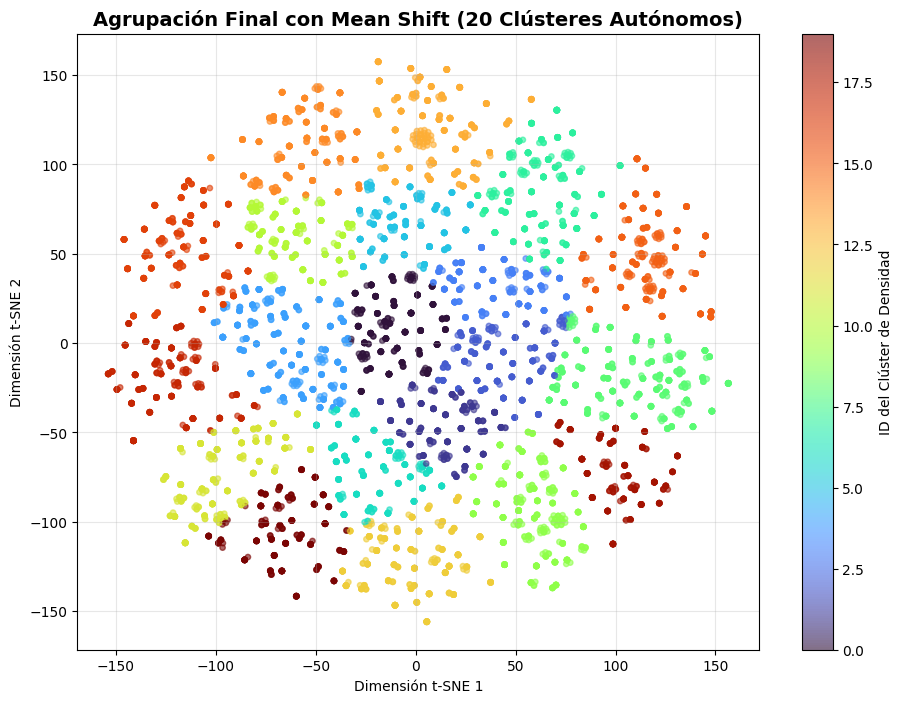


¡Proceso terminado! Encontró 20 grupos con un Silhouette Score de: 0.3289


In [ ]:
meanshift_modelo = MeanShift(bandwidth=bandwidth_estimado, bin_seeding=True)
preds_meanshift = meanshift_modelo.fit_predict(X_2d)
texto['cluster_meanshift'] = preds_meanshift
n_grupos_ms = len(set(preds_meanshift))
plt.figure(figsize=(11, 8))

scatter = plt.scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=preds_meanshift, cmap='turbo',
    alpha=0.6, s=15
)
plt.colorbar(scatter, label='ID del Clúster de Densidad')

plt.title(f'Agrupación Final con Mean Shift ({n_grupos_ms} Clústeres Autónomos)', fontsize=14, fontweight='bold')
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')
plt.grid(True, alpha=0.3)

plt.show()
if n_grupos_ms > 1:
    score_ms = silhouette_score(X_2d, preds_meanshift)
    print(f"\n¡Proceso terminado! Encontró {n_grupos_ms} grupos con un Silhouette Score de: {score_ms:.4f}")

##Observaciones
* A diferencia de los modelos anteriores, para Mean Shift se prescindió del uso de GridSearch. Se implementó la función heurística estimate_bandwidth, la cual calculó de forma automatizada un ancho de banda (bandwidth).
* El algoritmo resolvió de manera autónoma la detección de 20 clústeres. Visualmente, se observa un comportamiento híbrido: respeta las zonas de alta concentración (las cimas de acumulación de pacientes), pero al no poseer una métrica de exclusión de ruido, divide las regiones periféricas de forma continua, de manera similar a K-Means. Su Silhouette Score final se estableció en 0.3289.

#Validación
cruzada estratificada de 10 folds.

##K-Means

In [ ]:
X = X_2d
y = texto['prompt'].values
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores_folds = []
print("Iniciando Validación Cruzada Estratificada (10 Folds)...")
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
  X_train, X_test = X[train_idx], X[test_idx]
  y_test = y[test_idx]
  kmeans_fold = KMeans(n_clusters=7, random_state=42, n_init=10)
  kmeans_fold.fit(X_train)
  preds_test = kmeans_fold.predict(X_test)
  score = v_measure_score(y_test, preds_test)
  scores_folds.append(score)

  print(f"  Pliegue {fold}/10 terminado: V-Measure Score: {score:.4f}")

print("\n\n")
print(f"Resultado promedio de los 10 Folds: {np.mean(scores_folds):.4f}")
print(f"Desviación Estándar (Estabilidad): +/- {np.std(scores_folds):.4f}")

Iniciando Validación Cruzada Estratificada (10 Folds)...
  Pliegue 1/10 terminado: V-Measure Score: 0.5680
  Pliegue 2/10 terminado: V-Measure Score: 0.5723
  Pliegue 3/10 terminado: V-Measure Score: 0.5495
  Pliegue 4/10 terminado: V-Measure Score: 0.5702
  Pliegue 5/10 terminado: V-Measure Score: 0.5741
  Pliegue 6/10 terminado: V-Measure Score: 0.5834
  Pliegue 7/10 terminado: V-Measure Score: 0.5555
  Pliegue 8/10 terminado: V-Measure Score: 0.5845
  Pliegue 9/10 terminado: V-Measure Score: 0.5835
  Pliegue 10/10 terminado: V-Measure Score: 0.5521



Resultado promedio de los 10 Folds: 0.5693
Desviación Estándar (Estabilidad): +/- 0.0124


##Mean Shift


In [ ]:
X = X_2d
y = texto['prompt'].values
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores_folds = []
print("Iniciando Validación Cruzada Estratificada (10 Folds) Mean Shift...")
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
  X_train, X_test = X[train_idx], X[test_idx]
  y_test = y[test_idx]
  meanshift_fold = MeanShift(bandwidth=bandwidth_estimado, bin_seeding=True)
  meanshift_fold.fit(X_train)
  preds_test = meanshift_fold.predict(X_test)
  score = v_measure_score(y_test, preds_test)
  scores_folds.append(score)

  print(f"  Pliegue {fold}/10 terminado: V-Measure Score: {score:.4f}")

print("\n\n")
print(f"Resultado promedio de los 10 Folds: {np.mean(scores_folds):.4f}")
print(f"Desviación Estándar (Estabilidad): +/- {np.std(scores_folds):.4f}")

Iniciando Validación Cruzada Estratificada (10 Folds) Mean Shift...
  Pliegue 1/10 terminado: V-Measure Score: 0.6902
  Pliegue 2/10 terminado: V-Measure Score: 0.7096
  Pliegue 3/10 terminado: V-Measure Score: 0.7224
  Pliegue 4/10 terminado: V-Measure Score: 0.6851
  Pliegue 5/10 terminado: V-Measure Score: 0.7096
  Pliegue 6/10 terminado: V-Measure Score: 0.7203
  Pliegue 7/10 terminado: V-Measure Score: 0.6952
  Pliegue 8/10 terminado: V-Measure Score: 0.6954
  Pliegue 9/10 terminado: V-Measure Score: 0.7056
  Pliegue 10/10 terminado: V-Measure Score: 0.6981



Resultado promedio de los 10 Folds: 0.7031
Desviación Estándar (Estabilidad): +/- 0.0118


##DBSCAN

In [ ]:
X = X_2d

lista_grupos = []
lista_ruido = []
print("Validación de DBSCAN")
print("Simulando 10 extracciones independientes al 90% de los datos\n")
for i in range(1, 11):
  X_submuestra = resample(X, n_samples=int(len(X) * 0.90), random_state=i + 100)
  db_val = DBSCAN(eps=2.0, min_samples=5)
  labels_val = db_val.fit_predict(X_submuestra)
  grupos = len(set(labels_val)) - (1 if -1 in labels_val else 0)
  ruido = np.sum(labels_val == -1)
  lista_grupos.append(grupos)
  lista_ruido.append(ruido)
  print(f"  Simulación {i}/10 -> Clústeres: {grupos} \n\t Puntos de Ruido: {ruido}")
print("Resultados del analisis")
print(f"Promedio de grupos detectados: {np.mean(lista_grupos):.1f} (± {np.std(lista_grupos):.1f})")
print(f"Promedio de puntos de ruido:  {np.mean(lista_ruido):.1f} (± {np.std(lista_ruido):.1f})")

Validación de DBSCAN
Simulando 10 extracciones independientes al 90% de los datos

  Simulación 1/10 -> Clústeres: 578 
	 Puntos de Ruido: 1096
  Simulación 2/10 -> Clústeres: 606 
	 Puntos de Ruido: 1010
  Simulación 3/10 -> Clústeres: 613 
	 Puntos de Ruido: 1005
  Simulación 4/10 -> Clústeres: 588 
	 Puntos de Ruido: 1028
  Simulación 5/10 -> Clústeres: 598 
	 Puntos de Ruido: 1012
  Simulación 6/10 -> Clústeres: 591 
	 Puntos de Ruido: 1027
  Simulación 7/10 -> Clústeres: 614 
	 Puntos de Ruido: 960
  Simulación 8/10 -> Clústeres: 601 
	 Puntos de Ruido: 1001
  Simulación 9/10 -> Clústeres: 598 
	 Puntos de Ruido: 1017
  Simulación 10/10 -> Clústeres: 604 
	 Puntos de Ruido: 986
Resultados del analisis
Promedio de grupos detectados: 599.1 (± 10.6)
Promedio de puntos de ruido:  1014.2 (± 33.3)


##Observaciones
* La validacion cruzada unicamente funciona para K-Means y Mean Shift. Esto se debe a que K-means calcula los centroides y el algoritmo mide la distancia geometrica al centro mas cercano. Mean Shift lo hace localizando los centros de máxima densidad resultados del entrenamiento. Cuando el fold encuentra un dato nuevo, el algoritmo lo asigna dependiendo de la cima mas cercana. Mientras que DBSCAN aunque si calcula distancias  locales, depende de su continuidad y conectividad de la densidad global. Al segmentar los datos en pliegues aislados, se pierde la interconectividad del modelo por lo que requiere de una validacion distinta.

* K-Means: Divide el mapa de forma rígida en 7 regiones fijas. Como obliga a todos los pacientes a entrar en un grupo (aunque no encajen bien), su resultado es aceptable (V-Measure = 0.5693), pero la separación queda muy forzada para la variedad de los textos médicos.

* Mean Shift: Encontró por sí solo 20 zonas de alta concentración y agrupó los datos alrededor de ellas. Este modelo funcionó mejor para entender el significado real de lo que escribieron los pacientes, logrando el resultado de coincidencia externa más alto (V-Measure = 0.7031).

* DBSCAN (El Mejor Modelo): Es el mejor del proyecto porque no obliga a los datos a agruparse a la fuerza. Prefiere dejar fuera las frases raras o que hacen ruido (un 11.6% de casos sueltos) y concentrarse solo en los grupos que son muy claros y seguros. Gracias a esto, logra una calidad casi perfecta (Silhouette = 0.9509), creando grupos de síntomas muy puros y específicos.
